cuda
(569, 30)
(569,)


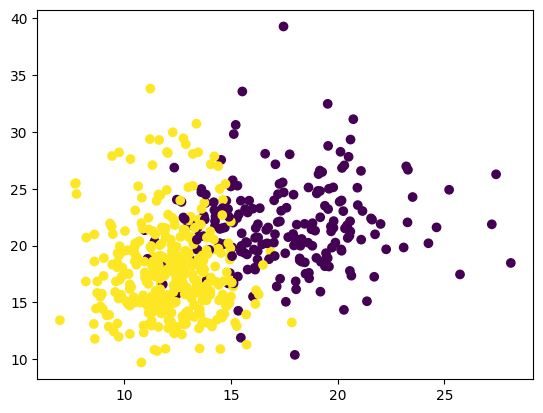

In [19]:
from kan import *
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

data = load_breast_cancer()
skf = StratifiedKFold(n_splits=5)


print(data.data.shape)
print(data.target.shape)
dtype = torch.get_default_dtype()
X = torch.from_numpy(data.data).type(dtype).to(device)
y = torch.from_numpy(data.target).type(dtype).to(device)
plt.scatter(X[:,0].cpu().detach().numpy(), X[:,1].cpu().detach().numpy(), c=y[:].cpu().detach().numpy())
plt.show()

Params: 4752


| train_loss: 1.94e-01 | test_loss: 1.89e-01 | reg: 0.00e+00 | : 100%|█| 250/250 [00:08<00:00, 29.80
| train_loss: 1.39e-01 | test_loss: 2.68e-01 | reg: 0.00e+00 | : 100%|█| 250/250 [00:08<00:00, 29.32
| train_loss: 1.72e-01 | test_loss: 1.74e-01 | reg: 0.00e+00 | : 100%|█| 250/250 [00:08<00:00, 29.56
| train_loss: 1.25e-01 | test_loss: 2.91e-01 | reg: 0.00e+00 | : 100%|█| 250/250 [00:07<00:00, 31.30
| train_loss: 1.66e-01 | test_loss: 2.05e-01 | reg: 0.00e+00 | : 100%|█| 250/250 [00:08<00:00, 31.22


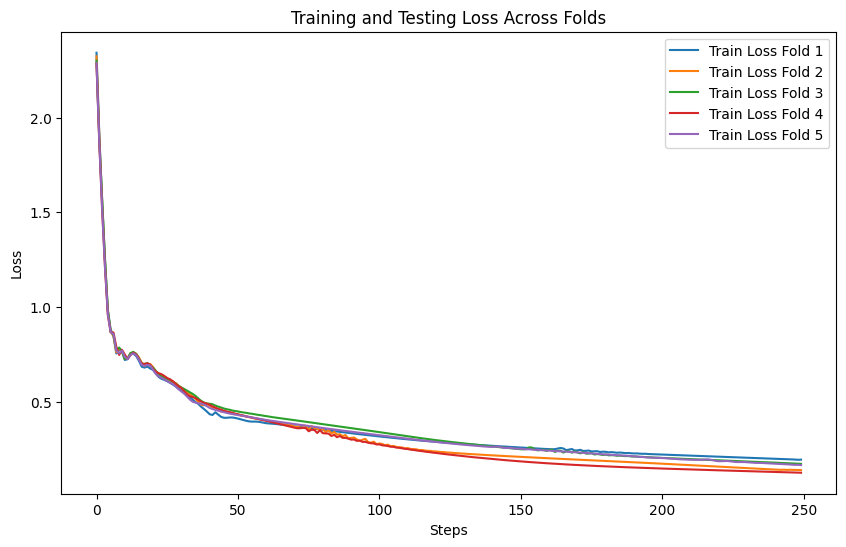

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
import time

dataset = {}
results = []
time_list = []

train_cms = []
test_cms = []

model = None

def train_acc_f():
    predictions = torch.argmax(model(dataset['train_input']), dim=1)
    return torch.mean((predictions == dataset['train_label']).type(dtype))
def test_acc_f():
    predictions = torch.argmax(model(dataset['test_input']), dim=1)
    return torch.mean((predictions == dataset['test_label']).type(dtype))

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()  # Extract confusion matrix components
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='binary'),
        "recall": recall_score(y_true, y_pred, average='binary'),
        "f1_score": f1_score(y_true, y_pred, average='binary'),
        "fpr": fpr,
        "fnr": fnr
    }
    return metrics

# depth-3 about optimal shape
layer=11
KAN_width=[data.data.shape[1], layer, layer, layer, 2]
KAN_g=3
KAN_k=3
n_params = 0
for i in range(len(KAN_width)-1):
    n_params += KAN_width[i]*KAN_width[i+1]*(KAN_g+KAN_k+2)
print("Params:", n_params)

kan_train_metrics = []
kan_test_metrics = []
for i, (train_index, test_index) in enumerate(skf.split(data.data, data.target)):
    dataset['train_input'] = torch.from_numpy(data.data[train_index]).type(torch.FloatTensor).to(device)
    dataset['test_input'] = torch.from_numpy(data.data[test_index]).type(torch.FloatTensor).to(device)
    dataset['train_label'] = torch.from_numpy(data.target[train_index]).type(torch.LongTensor).to(device)
    dataset['test_label'] = torch.from_numpy(data.target[test_index]).type(torch.LongTensor).to(device)

    model = KAN(width=KAN_width, grid=KAN_g, k=KAN_k, device=device, save_act=False, auto_save=False, seed=1)

    start_time = time.time()
    results.append(model.fit(dataset, opt="Adam", steps=250, loss_fn=torch.nn.CrossEntropyLoss(), lr=0.005))
    end_time = time.time()
    time_list.append(end_time - start_time)

    train_predictions = torch.argmax(model(dataset['train_input']), dim=1).cpu().numpy()
    test_predictions = torch.argmax(model(dataset['test_input']), dim=1).cpu().numpy()

    train_labels = dataset['train_label'].cpu().numpy()
    test_labels = dataset['test_label'].cpu().numpy()

    #metrics
    kan_train_metrics.append(compute_metrics(train_labels, train_predictions))
    kan_test_metrics.append(compute_metrics(test_labels, test_predictions))
    train_cms.append(confusion_matrix(train_labels, train_predictions))
    test_cms.append(confusion_matrix(test_labels, test_predictions))
    


plt.figure(figsize=(10, 6))

for i, result in enumerate(results):
    plt.plot(result['train_loss'], label=f'Train Loss Fold {i+1}')


plt.legend()
plt.ylabel('Loss')
plt.xlabel('Steps')
plt.title('Training and Testing Loss Across Folds')
plt.yscale('linear')
plt.show()

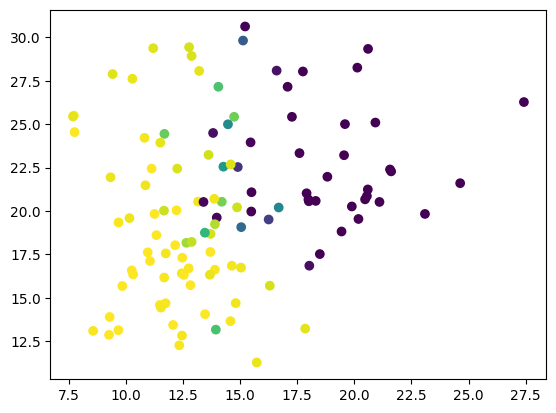

In [21]:
X = dataset['test_input']
y = model.forward(dataset['test_input'])[:, 1]
y_normalized = 1/(1 + np.exp(-y.cpu().detach().numpy()))

plt.scatter(X[:,0].cpu().detach().numpy(), X[:,1].cpu().detach().numpy(), c=y_normalized)
plt.show()

Train Metrics:
accuracy: 0.9921 ± 0.0043
precision: 0.9923 ± 0.0034
recall: 0.9951 ± 0.0036
f1_score: 0.9937 ± 0.0034
fpr: 0.0130 ± 0.0058
fnr: 0.0049 ± 0.0036

Test Metrics:
accuracy: 0.9824 ± 0.0096
precision: 0.9835 ± 0.0160
recall: 0.9888 ± 0.0056
f1_score: 0.9861 ± 0.0076
fpr: 0.0280 ± 0.0271
fnr: 0.0112 ± 0.0056

Time Metrics: 8.2783 ± 0.2308


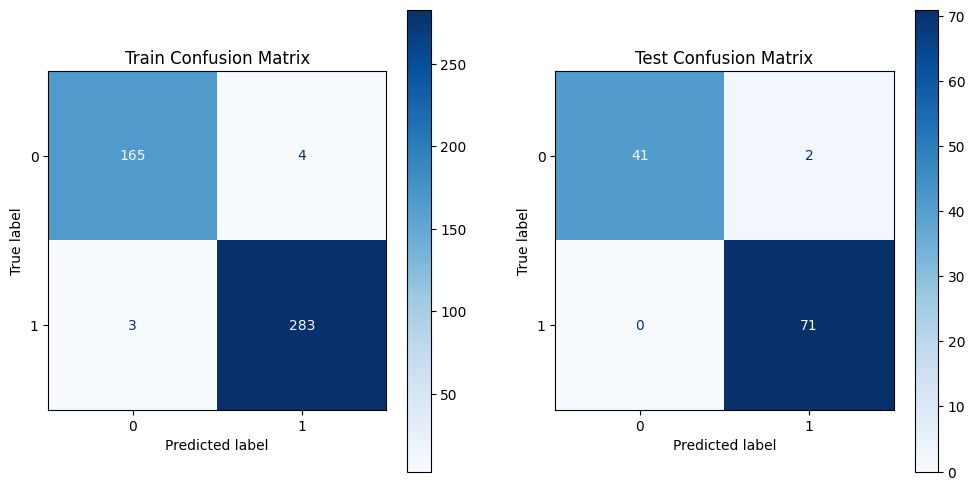

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np

def aggregate_metrics(metrics_list):
    aggregated = {}
    for key in metrics_list[0].keys():
        values = [metrics[key] for metrics in metrics_list]
        aggregated[key] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
    return aggregated
def aggregate_time(time_list):
    aggregated = {
        "mean": np.mean(time_list),
        "std": np.std(time_list)
    }
    return aggregated

train_metrics_summary = aggregate_metrics(kan_train_metrics)
test_metrics_summary = aggregate_metrics(kan_test_metrics)
time_metrics_summary = aggregate_time(time_list)

print("Train Metrics:")
for key, value in train_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print("\nTest Metrics:")
for key, value in test_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print(f"\nTime Metrics: {time_metrics_summary['mean']:.4f} ± {time_metrics_summary['std']:.4f}")


with open(f"KAN_{n_params}.txt", "w") as file:
    mean=test_metrics_summary["accuracy"]["mean"]
    std=test_metrics_summary["accuracy"]["std"]
    file.write(f"{mean:.4f} {std:.4f}\n")


fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ConfusionMatrixDisplay(train_cms[0]).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Train Confusion Matrix')
ConfusionMatrixDisplay(test_cms[0]).plot(ax=ax[1], cmap='Blues')
ax[1].set_title('Test Confusion Matrix')

plt.show()

MLP

Params: 4901
Train Metrics: {'accuracy': {'mean': np.float64(0.9218016194331984), 'std': np.float64(0.012485084551757734)}, 'precision': {'mean': np.float64(0.922897148720268), 'std': np.float64(0.014750524233057666)}, 'recall': {'mean': np.float64(0.9558851674641147), 'std': np.float64(0.03139467147179526)}, 'f1_score': {'mean': np.float64(0.9385975963300176), 'std': np.float64(0.011054857534560628)}, 'fpr': {'mean': np.float64(0.13565610859728508), 'std': np.float64(0.03161927742207815)}, 'fnr': {'mean': np.float64(0.04411483253588516), 'std': np.float64(0.031394671471795275)}}
Test Metrics: {'accuracy': {'mean': np.float64(0.8980282564819128), 'std': np.float64(0.0241210429994513)}, 'precision': {'mean': np.float64(0.9086385836385835), 'std': np.float64(0.040327897750342075)}, 'recall': {'mean': np.float64(0.9354851330203443), 'std': np.float64(0.05234887983904314)}, 'f1_score': {'mean': np.float64(0.919828892981517), 'std': np.float64(0.019461483555349515)}, 'fpr': {'mean': np.floa

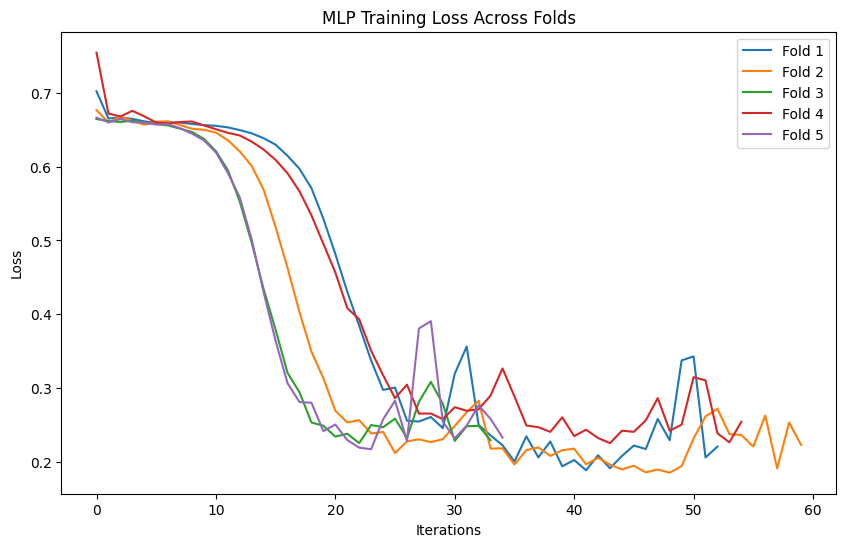

In [23]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import time

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()  # Extract confusion matrix components
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='binary'),
        "recall": recall_score(y_true, y_pred, average='binary'),
        "f1_score": f1_score(y_true, y_pred, average='binary'),
        "fpr": fpr,
        "fnr": fnr
    }
    return metrics

#depth-4 about optimal shape
leyer=35
hidden_layer_size = (leyer, leyer,leyer, leyer)
params=(data.data.shape[1], *hidden_layer_size, 1)
n_params = 0
for i in range(len(params)-1):
    n_params += params[i]*params[i+1]+params[i+1]
print("Params:", n_params)

results = []
train_metrics = []
test_metrics = []
time_list = []

for train_index, test_index in skf.split(data.data, data.target):
    train_input = data.data[train_index]
    train_label = data.target[train_index]
    test_input = data.data[test_index]
    test_label = data.target[test_index]
    
    mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_size, activation='logistic', solver='adam', max_iter=250, learning_rate_init=0.005)
    
    start_time = time.time()
    mlp.fit(train_input, train_label)
    end_time = time.time()
    time_list.append(end_time - start_time)
    
    train_predictions = mlp.predict(train_input)
    test_predictions = mlp.predict(test_input)

    results.append(mlp.loss_curve_)
    train_metrics.append(compute_metrics(train_label, train_predictions))
    test_metrics.append(compute_metrics(test_label, test_predictions))

train_metrics_summary = aggregate_metrics(train_metrics)
test_metrics_summary = aggregate_metrics(test_metrics)

print("Train Metrics:", train_metrics_summary)
print("Test Metrics:", test_metrics_summary)

plt.figure(figsize=(10, 6))
for i, loss_curve in enumerate(results):
    plt.plot(loss_curve, label=f'Fold {i+1}')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Training Loss Across Folds')
plt.legend()
plt.show()

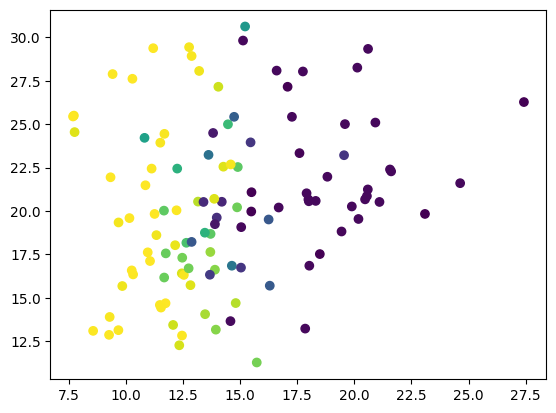

In [24]:
X = dataset['test_input']
y = mlp.predict_proba(dataset['test_input'].cpu().numpy())[:, 1]
plt.scatter(X[:,0].cpu().detach().numpy(), X[:,1].cpu().detach().numpy(), c=y)
plt.show()

Train Metrics:
accuracy: 0.9218 ± 0.0125
precision: 0.9229 ± 0.0148
recall: 0.9559 ± 0.0314
f1_score: 0.9386 ± 0.0111
fpr: 0.1357 ± 0.0316
fnr: 0.0441 ± 0.0314

Test Metrics:
accuracy: 0.8980 ± 0.0241
precision: 0.9086 ± 0.0403
recall: 0.9355 ± 0.0523
f1_score: 0.9198 ± 0.0195
fpr: 0.1646 ± 0.0865
fnr: 0.0645 ± 0.0523

Time Metrics: 0.1819 ± 0.0557


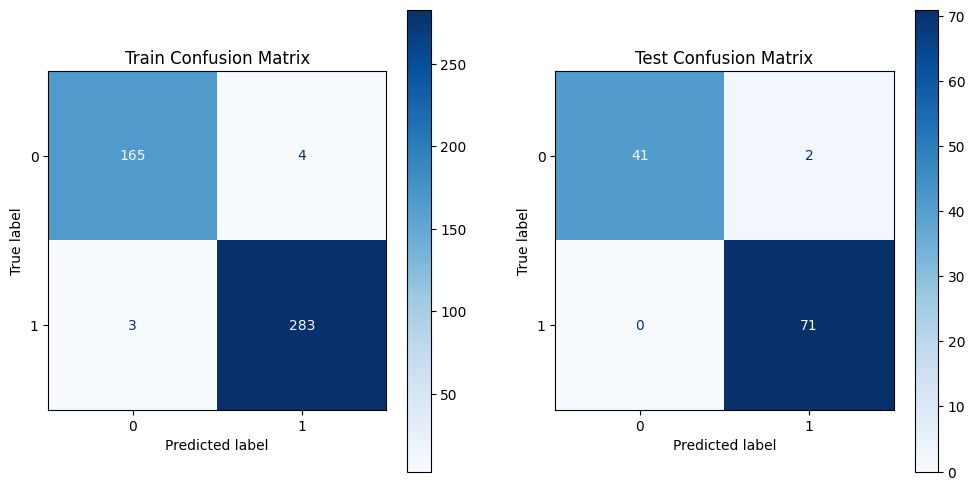

In [25]:
def aggregate_metrics(metrics_list):
    aggregated = {}
    for key in metrics_list[0].keys():
        values = [metrics[key] for metrics in metrics_list]
        aggregated[key] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
    return aggregated

def aggregate_time(time_list):
    aggregated = {
        "mean": np.mean(time_list),
        "std": np.std(time_list)
    }
    return aggregated


train_metrics_summary = aggregate_metrics(train_metrics)
test_metrics_summary = aggregate_metrics(test_metrics)
time_metrics_summary= aggregate_time(time_list)

print("Train Metrics:")
for key, value in train_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print("\nTest Metrics:")
for key, value in test_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print(f"\nTime Metrics: {time_metrics_summary['mean']:.4f} ± {time_metrics_summary['std']:.4f}")

with open(f"MLP_{n_params}.txt", "w") as file:
    mean=test_metrics_summary["accuracy"]["mean"]
    std=test_metrics_summary["accuracy"]["std"]
    file.write(f"{mean:.4f} {std:.4f}\n")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ConfusionMatrixDisplay(train_cms[0]).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Train Confusion Matrix')
ConfusionMatrixDisplay(test_cms[0]).plot(ax=ax[1], cmap='Blues')
ax[1].set_title('Test Confusion Matrix')

plt.show()